Assignment 2:

Name:

UID:

Please submit to Gradescope

A PDF containing all outputs (by executing Run all)
Your ipynb notebook containing all the code
I understand the policy on academic integraty (collaboration and the use of online material).

Please sign your name here:



This notebook is to help finish Lucas-Kanade algorithm

In [1]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
import os, sys, time
%matplotlib inline

# Feature Tracker (100 points)

# Overview

In the problem, you will implement a corner detector and feature tracker that track features from the image sequence hotel. Since this is a two part problem, we have included precomputed intermediate results in the *Data* section in case you’re unable to complete any portion.


<img src="https://drive.google.com/uc?export=view&id=15GfDPRdRUg2xbZnXMZKZePYK_C9z9LHl" width="800"/>


**Note:**  Do not use existing keypoint
detectors, trackers, or structure from motion code, such as found on the web, and OpenCV.

In [2]:
# Download Data -- run this cell only one time per runtime
import gdown
url = "https://drive.google.com/uc?id=1L5oV8H7EEh5ggncOYThBB4OXdGYPozqA"
output = "HW2_files.zip"  # Change this to your desired file name
gdown.download(url, output, quiet=False)
!unzip "/content/HW2_files.zip" -d "/content/"

# # Load Initial Key Points
data = np.load('/content/HW2_files/initial_keypoints.npz')
X0 = data['X0']
Y0 = data['Y0']

print(X0.shape)
print(Y0.shape)
key_pts = np.concatenate((X0, Y0), axis=1)
print(key_pts.shape)
print(key_pts)

Downloading...
From: https://drive.google.com/uc?id=1L5oV8H7EEh5ggncOYThBB4OXdGYPozqA
To: /content/HW2_files.zip
100%|██████████| 5.12M/5.12M [00:00<00:00, 67.2MB/s]


Archive:  /content/HW2_files.zip
   creating: /content/HW2_files/
  inflating: /content/HW2_files/.DS_Store  
  inflating: /content/__MACOSX/HW2_files/._.DS_Store  
   creating: /content/HW2_files/images/
  inflating: /content/__MACOSX/HW2_files/._images  
  inflating: /content/HW2_files/initial_keypoints.npz  
  inflating: /content/__MACOSX/HW2_files/._initial_keypoints.npz  
  inflating: /content/HW2_files/images/hotel.seq41.png  
  inflating: /content/__MACOSX/HW2_files/images/._hotel.seq41.png  
  inflating: /content/HW2_files/images/hotel.seq40.png  
  inflating: /content/__MACOSX/HW2_files/images/._hotel.seq40.png  
  inflating: /content/HW2_files/images/hotel.seq42.png  
  inflating: /content/__MACOSX/HW2_files/images/._hotel.seq42.png  
  inflating: /content/HW2_files/images/hotel.seq43.png  
  inflating: /content/__MACOSX/HW2_files/images/._hotel.seq43.png  
  inflating: /content/HW2_files/images/hotel.seq47.png  
  inflating: /content/__MACOSX/HW2_files/images/._hotel.seq47.p

In [3]:
def readImages(folder, num_images):
  arr_images = []
  for i in range(num_images):
    arr_images.append(cv2.imread(f'{folder}hotel.seq{i}.png'))
  return np.array(arr_images, dtype=np.float32)

# read all 51 sequences of images
folder = '/content/HW2_files/images/'
im = readImages(folder, 51)

# 1.1 Keypoint Selection - Harris Corner Detection (30 pts)

<!-- For the first frame, use the second moment matrix to locate strong corners to use as keypoints. -->
<!-- These points will be tracked throughout the sequence in the second part of the problem. -->
In the class, we know that we approximate the Sum Square Distance (SSD) error by Tylor expansion in to this form:

<img src="https://drive.google.com/uc?export=view&id=17NFShMMDvNGdYMW4R_yWtsgb-LtlHiQv" width="350"/>

where $w_{x,y}$ is 2D Gaussian filter, and the H matrix:

<img src="https://drive.google.com/uc?export=view&id=18k93e4q6ix7v200IsHtMZAyjpqyafV19" width="350"/>


In this section, you will need to implement the function of Harris Corner Detection by constructing the approximated SSD error matrix and Harris operator:

<!-- <img src="https://drive.google.com/uc?export=view&id=1JNjzdYDfkwlzD9EUI-l4JmX3Tt_dq6d5" width="200"/> -->

\begin{equation}
f = \frac{λ_1 λ_2}{λ_1 + λ_2} \\
  = \frac{determinant(H)}{trace(H)}
\end{equation}

Follow the instructions in the code block, check with the formula above if needed.

Hint:
* Choose a proper threshold so that edges and noisy patches are ignored.
* Do local non-maxima suppression over a 5x5 window centered at each point.

This should give several hundred good points to track.

### Code - Harris Corner Detection (10 pts)

In [4]:
def HarrisCornerDet(img, tau):
  '''
  Detecting keypoints using Harris corner criterion

  Parameters:
    img: input image
    tau: threshold for Harris operator f

  Steps:
  1. Convert image to grayscale
  2. Smooth the image
  3. Compute image gradients: Ix, Iy, IxIy
  4. Create structure tensor H = [ Σ(Ix²)  Σ(IxIy) ]
                                 [ Σ(IxIy) Σ(Iy²)  ]
  5. Compute Harris operator f = determinant (H) / trace(H)
      - Hint: Remember to normalize f to [0,1]
  6. Non-maximum suppression
      - Hint: You can use ndimage.maximum_filter to create max_filter

  * Remember to add plots below for the write-up

  Output:
    keypoints : (N,2) array of [x,y] keypoints
  '''
  # Parameters given
  smooth_window_size = 7
  nms_window_size = 5

  ###### YOUR CODE HERE ######
  # Step 1: Convert image to grayscale


  # Step 2: Smooth the image

  # Step 3: Compute image gradients: Ix², Iy², IxIy

  # Step 4: Prepare elements for Structure Tensor H
  # H = [ Σ(Ix²)  Σ(IxIy) ]
  #     [ Σ(IxIy) Σ(Iy²)  ]


  # Step 5: Compute Harris operator f = determinant (H) / trace(H)
  # - Hint: Remember to normalize f to [0,1]

  # Step 6: Non-maximum suppression
  # - Hint: You can use ndimage.maximum_filter to create max_filter
  return key_pts

## Test your codes

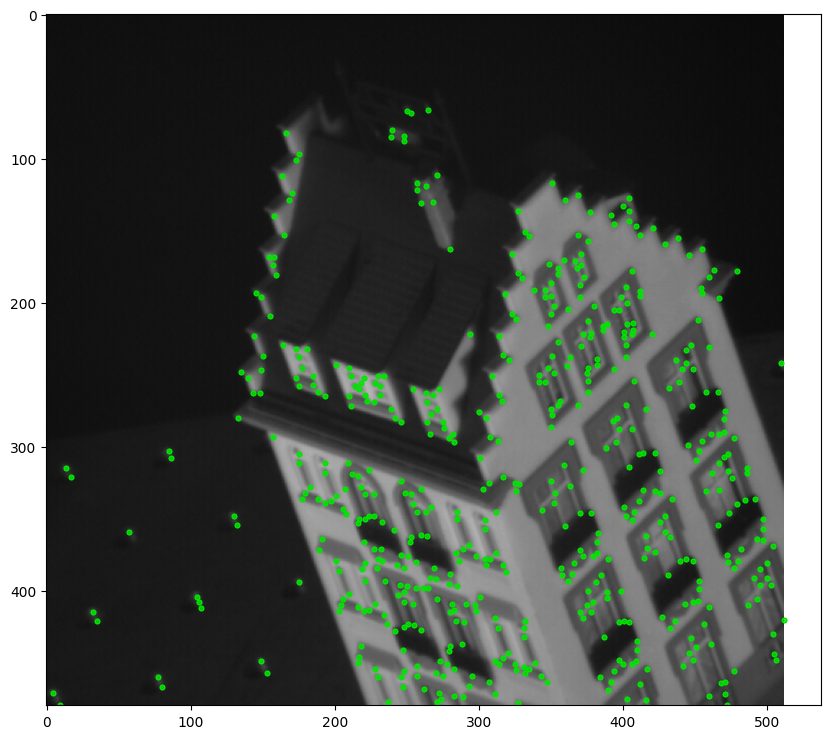

In [5]:
# Parameter setting
tau = 0.06

# Run Harris corner detection
key_pts_detected = HarrisCornerDet(im[0], tau)

# add plots for the write-up
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im[0] / 255)
plt.scatter(key_pts_detected[:, 0], key_pts_detected[:, 1], color=(0,0.9,0), linewidths=3, s=2)
plt.show()

### Reference result

* Your result should look similar to this figure:

<img src="https://drive.google.com/uc?export=view&id=1M4T2fXcwWp2YkpvnVjk7RBgEhwNDc-Vh" width="800"/>


## Write-up (40 pts)


*   (5 pts) Explain your implementation of HarrisCornerDet()
*   (5 pts) Display the first frame of the sequence overlaid with the detected keypoints. Ensure that they are clearly visible (plot with `color='g' and linewidths=3`)



**Include your write-up here**

# 1.2 Feature Tracking (70 pts)

**Description**
* Apply the Kanade-Lucas-Tomasi tracking procedure to track the keypoints found in part 1.1 (or the given keypoints in the *Data* section) throughout the hotel sequence.
* Steps for Iterative Lucas-Kanade

  <img src="https://drive.google.com/uc?export=view&id=1d4Dkx_9dLJ283J8QXF2QxALysldGBe-X" width="700"/>


* Some keypoints will move out of the image frame over the course of the sequence. Discard keypoints for which the predicted translation falls outside the image frame.

**Hint:**
* How to get (u, v)? Solve Ax=b. You can utilize np.linalg.solve()

  <img src="https://drive.google.com/uc?export=view&id=1JFtJRSxtdsVmyxeJywBLuHY8u3VDsdVj" width="450"/>


*  From the 1st frame to the 2nd frame, use the detected keypoints at the first frame as initialization points. From the 2nd to 3rd frame, use the tracked positions at the 2nd frame as initialization. Note that the tracked keypoints in general are not at integer positions.

*  For each point, use a window size of 15 x 15.

Add code to **plot** your tracked points overlayed in the **first sequence** and the **last sequence**. They should look similar to the second picture shown in the Overview section.



## Code - Lucas-Kanade

# Helper Function

In [ ]:
'''
Feel free to use the functions below in your implementation.
It's not necessarily to use them, you can have your own implementation

'''

def resize(im, scale):
  if scale < 1:
    im = cv2.GaussianBlur(im, (9, 9), 2)
  im = cv2.resize(im, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
  return im

def get_windows(spline, cx, cy, half_size):
  x_grids = np.linspace(cx - half_size, cx + half_size, half_size * 2 + 1).transpose()
  y_grids = np.linspace(cy - half_size, cy + half_size, half_size * 2 + 1).transpose()
  samples = []
  for x_grid, y_grid in zip(x_grids, y_grids):
    x_meshgrid, y_meshgrid = np.meshgrid(x_grid, y_grid, indexing='xy')
    sample = spline.ev(xi=x_meshgrid, yi=y_meshgrid)
    samples.append(sample)
  return np.stack(samples)

# Complete the code - Lucas-Kanade

In [ ]:
def compute_gradients(img):
  """
  Computes the image gradients in the x and y directions using the central difference method.

  Parameters:
  ----------
  img : numpy.ndarray
      Input grayscale image of shape (H, W), where H is the height and W is the width.

  Returns:
  -------
  Ix : numpy.ndarray
      Gradient of the image in the x-direction, shape (H, W).

  Iy : numpy.ndarray
      Gradient of the image in the y-direction, shape (H, W).

  Notes:
  ------
  - The function applies the central difference formula:
      Ix(x, y) ≈ (I(x+1, y) - I(x-1, y)) / 2
      Iy(x, y) ≈ (I(x, y+1) - I(x, y-1)) / 2
  - You can do zero-padding for the boundary pixels if needed.
  """
  Ix = np.zeros_like(img)
  Iy = np.zeros_like(img)
  #### YOUR CODE HERE ####


  #### YOUR CODE HERE ####
  return Ix, Iy

def valid_range_check(x, y, height, width, ws):
  """
    Checks whether the given points (x, y) are within the valid range of the image.

    Parameters:
    ----------
    x : numpy.ndarray or int
        X-coordinates of the points to check, shape (N,) or (1,).

    y : numpy.ndarray or int
        Y-coordinates of the points to check, shape (N,) or (1,).

    height : int
        Height of the image.

    width : int
        Width of the image.

    ws : int
        Window size, defining the margin around the image boundary where points are considered invalid.

    Returns:
    -------
    valid_mask : numpy.ndarray
        Boolean mask indicating whether each point is within the valid range, shape (N,).

    Notes:
    ------
    - A point (x, y) is considered valid if:
        ws ≤ x < width - ws
        ws ≤ y < height - ws
    - If `x` and `y` are numpy arrays, the function returns an array of the same shape.
  """
  #### YOUR CODE HERE ####

  return valid_mask
  #### YOUR CODE HERE ####

def iterative_Lucaskanade(x1, y1, img1, img2, ws, iteration=10, thresh=0.4):
  """
  Performs iterative Lucas-Kanade feature tracking to estimate optical flow.

  Parameters:
  ----------
  x1 : numpy.ndarray
      Initial x-coordinates of feature points, shape (N,).

  y1 : numpy.ndarray
      Initial y-coordinates of feature points, shape (N,).

  img1 : numpy.ndarray
      First (reference) grayscale image, shape (H, W).

  img2 : numpy.ndarray
      Second grayscale image (target frame for tracking), shape (H, W).

  ws : int
      Window size around each feature point for computing local gradients.

  iteration : int, optional (default=10)
      Maximum number of iterations for iterative refinement.

  thresh : float, optional (default=0.4)
      Convergence threshold; tracking stops if the mean motion change is below this value.

  Returns:
  -------
  x2 : numpy.ndarray
      Estimated x-coordinates of tracked feature points in img2, shape (N,).

  y2 : numpy.ndarray
      Estimated y-coordinates of tracked feature points in img2, shape (N,).

  Notes:
  ------
  - The method initializes points at (x1, y1) and refines them iteratively using local gradients.
  - Image gradients are computed using central differences.
  - A least-squares system is solved for each feature point to estimate movement.
  - The tracking is refined until either `iteration` is reached or displacement change is below `thresh`.
  - Uses `RectBivariateSpline` for subpixel interpolation.
  """
  # Step 0: Initialize points. No need to change.
  x2 = x1.copy()
  y2 = y1.copy()

  N = x1.shape[0]
  H, W = img1.shape

  ###### YOUR CODE HERE ######
  # Step 1: Calculate gradients Ix2, Iy2, Ixy. TODO: Finish `compute_gradients()`
  Ix, Iy = compute_gradients(img1)

  # TODO: Compute Ix2 = Ix * Ix, Iy2 = Iy * Iy, Ixy = Ix * Iy

  # Step 2: Setup interpolation for gradient and intensity. No need to change.
  y_grid = np.arange(0, H)
  x_grid = np.arange(0, W)
  # RectBivariateSpline() provides an interpolation sampler so that you can sample sub-pixel values on a grid
  spline_Ix = RectBivariateSpline(x=x_grid, y=y_grid, z=Ix.transpose(1, 0))
  spline_Iy = RectBivariateSpline(x=x_grid, y=y_grid, z=Iy.transpose(1, 0))
  spline_img1 = RectBivariateSpline(x=x_grid, y=y_grid, z=img1.transpose(1, 0))
  spline_img2 = RectBivariateSpline(x=x_grid, y=y_grid, z=img2.transpose(1, 0))


  # Step 3: Iterate through iterations
  for i in range(iteration):
    # Step 3.1: Get points within valid range. TODO: Finish valid_range_check()
    mask1 = valid_range_check(x1, y1, H, W, ws)
    mask2 = valid_range_check(x2, y2, H, W, ws)
    mask = mask1 * mask2
    x1_ = x1[mask]
    y1_ = y1[mask]
    x2_ = x2[mask]
    y2_ = y2[mask]
    assert mask.sum() > 0


    uv = np.zeros((len(x1_), 2))  # Store displacement per point
    # Traverse each point
    for idx in range(len(x1_)):
      # Step 3.2: Calculate matrix ATA and ATb.
      x, y = x1_[idx:idx+1], y1_[idx:idx+1]
      x_next, y_next = x2_[idx:idx+1], y2_[idx:idx+1]

      # Get windowed gradient values
      Ix_window = get_windows(spline_Ix, x, y, ws)
      Iy_window = get_windows(spline_Iy, x, y, ws)

      # Compute elements of the structure tensor
      # TODO: compute sum for Ix2, Ixy, Iy2 for each window
      # sum over (Ix_windows * Ix_windows)
      # sum over (Iy_windows * Iy_windows)
      # sum over (Ix_windows * Iy_windows)
      Ixx_sum = ???
      Iyy_sum = ???
      Ixy_sum = ???

      # Compute intensity difference
      t1_window = get_windows(spline_img1, x1_, y1_, ws)
      t2_window = get_windows(spline_img2, x2_, y2_, ws)

      # TODO: update the temporal gradient It
      It_window = ???

      # TODO: compute sum over
      # Ix_window * It_window
      # Iy_window * It_window
      Ixt_sum = ???
      Iyt_sum = ???

      # Step 3.3: Solve least squares by getting ATAx = ATb: x = (ATA)^(-1)ATb
      # - Hint: solve by np.linalg.solve()
      # ATA =   # shape: (2, 2)
      # ATb =   # shape (2,)
      # uv[idx] = np.linalg.solve(ATA, ATb)
      ATA = ???
      ATb = ???

      # Step 3.4 Update u, v movement to x2, y2 to get x2_, y2_
      x2_[idx]       #complete here
      y2_[idx]       #complete here


    # early stop if the shift changes little. no need to change below
    shift = np.sqrt(np.square(uv[:, 0]) + np.square(uv[:, 1])).mean()
    print('iteration:', i, ', shift_uv_mean:', shift)

    if shift < thresh:
      break

    # assign values to valid points.
    x2[mask] = x2_
    y2[mask] = y2_

  return x2, y2

#no need to change this code
def getNextPoints(x1, y1, img1, img2, ws, iteration=10):
  '''
  Iterative Lucas-Kanade feature tracking
  x,  y : initialized keypoint position in im2
  ws: patch window size
  iteration: parameter to control how many iterations to run in iterative_LucasKanade function

  output: tracked keypoint positions in im2
  '''

  # Step 1: convert RGB images to gray image and apply Gaussian blur
  img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
  img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
  img1 = cv2.GaussianBlur(img1, (13, 13), 3)
  img2 = cv2.GaussianBlur(img2, (13, 13), 3)

  # Step 2: Iterative Lucas-Kanade feature tracking
  x2, y2 = iterative_Lucaskanade(x1, y1, img1, img2, ws, iteration)

  return x2, y2

# Code below for checking the iterative_Lucaskanade, no need to change any code below

### Sanity Check 1: compute_gradients()


You gradients should look similar to cv2.Sobel(). There is a slight difference between
two because of cv2's own implementation.




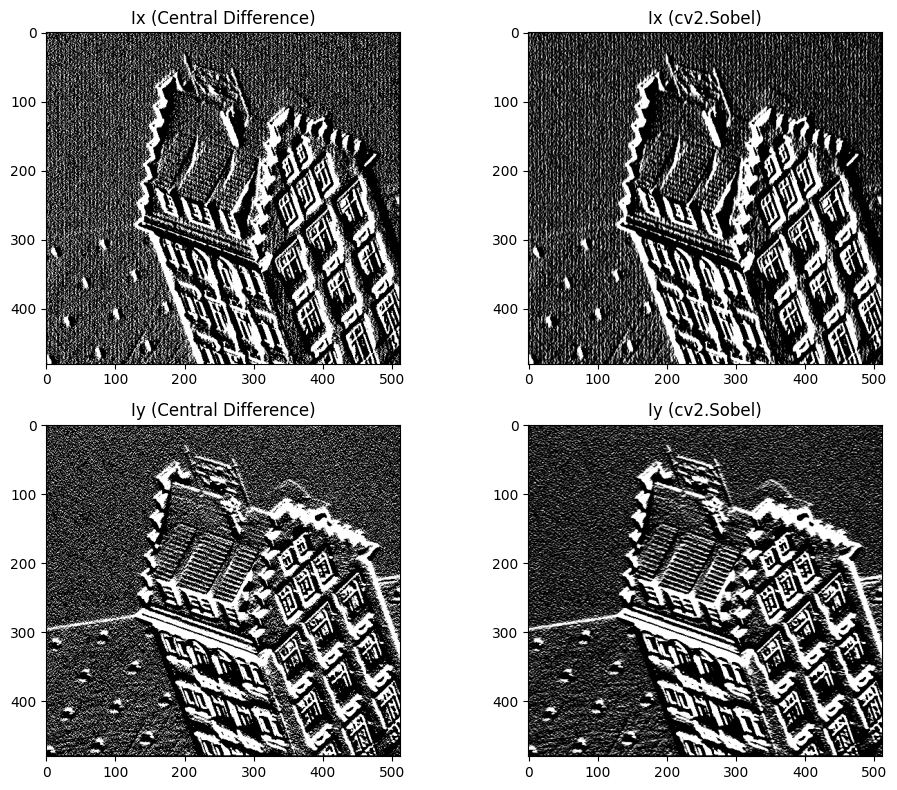

In [ ]:
# Compute gradients using NumPy central difference
Ix_central, Iy_central = compute_gradients(im[0].astype(np.float64))

# Compute gradients using OpenCV Sobel (ksize=3 for central difference)
Ix_sobel = cv2.Sobel(im[0].astype(np.float64), cv2.CV_64F, 1, 0, ksize=3) / 8.0  # Normalize by 8 to match central diff scaling
Iy_sobel = cv2.Sobel(im[0].astype(np.float64), cv2.CV_64F, 0, 1, ksize=3) / 8.0

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(Ix_central, cmap='gray')
axes[0, 0].set_title('Ix (Central Difference)')

axes[0, 1].imshow(Ix_sobel, cmap='gray')
axes[0, 1].set_title('Ix (cv2.Sobel)')

axes[1, 0].imshow(Iy_central, cmap='gray')
axes[1, 0].set_title('Iy (Central Difference)')

axes[1, 1].imshow(Iy_sobel, cmap='gray')
axes[1, 1].set_title('Iy (cv2.Sobel)')

plt.tight_layout()
plt.show()

### Sanity Check 2: valid_range_check()


In [ ]:
import unittest

class TestValidRangeCheck(unittest.TestCase):
    def test_inside_valid_range(self):
        self.assertTrue(valid_range_check(5, 5, 10, 10, 2), f"Expected True for (5, 5) in 10x10 with ws=2")
        self.assertTrue(valid_range_check(3, 3, 8, 8, 2), f"Expected True for (3, 3) in 8x8 with ws=2")

    def test_outside_valid_range(self):
        self.assertFalse(valid_range_check(1, 1, 10, 10, 2), f"Expected False for (1, 1) in 10x10 with ws=2")
        self.assertFalse(valid_range_check(9, 9, 10, 10, 2), f"Expected False for (9, 9) in 10x10 with ws=2")
        self.assertFalse(valid_range_check(0, 0, 10, 10, 2), f"Expected False for (0, 0) in 10x10 with ws=2")

    def test_minimum_valid_case(self):
        self.assertTrue(valid_range_check(2, 2, 5, 5, 2), f"Expected True for (2, 2) in 5x5 with ws=2")

    def test_maximum_valid_case(self):
        self.assertFalse(valid_range_check(2, 2, 4, 4, 2), f"Expected False for (2, 2) in 4x4 with ws=2 (no valid space)")

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

....
----------------------------------------------------------------------
Ran 4 tests in 0.003s

OK


In [ ]:
def trackPoints(pt_x, pt_y, im, ws, iteration):
  '''
  Tracking initial points (pt_x, pt_y) across the image sequence
  Inputs:
  pt_x: initialized keypoint position of x
  pt_y: initialized keypoint position of y
  im: image sequence (N frames)
  ws: patch window size
  iteration: controls how many iterations to run in iterative_LucasKanade

  Outputs:
    track_x: [Number of keypoints] x [2]
    track_y: [Number of keypoints] x [2]
  '''
  N = np.prod(pt_x.shape)
  nim = len(im)
  track_x = np.zeros((N, nim))
  track_y = np.zeros((N, nim))
  track_x[:,0] = pt_x
  track_y[:,0] = pt_y
  for t in range(nim - 1):
    track_x[:, t+1], track_y[:, t+1] = getNextPoints(track_x[:, t], track_y[:, t], im[t,:,:], im[t+1,:,:], ws, iteration)

  return track_x, track_y

### Sanity Check 3: Tracking 1 point with synthetic motion

(1, 2)


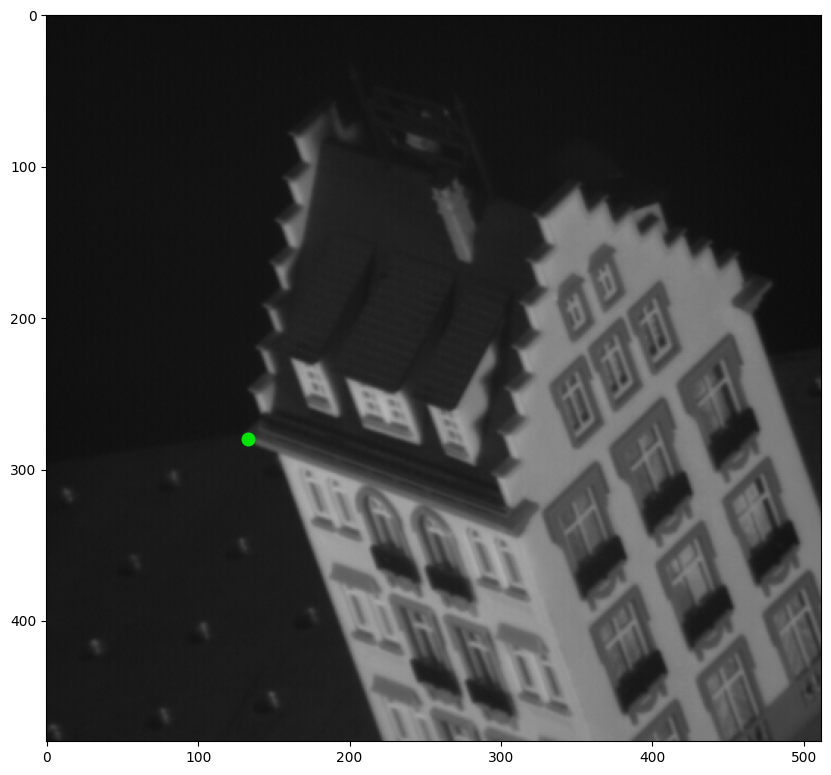

In [ ]:
# Let's start by using only one point
index = 16
key_pt = key_pts[index:index+1]
print(key_pt.shape)
im0 = im[0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im0 / 255)
plt.scatter(key_pt[:, 0], key_pt[:, 1], color=(0,0.9,0), linewidths=3, s=50)
plt.show()

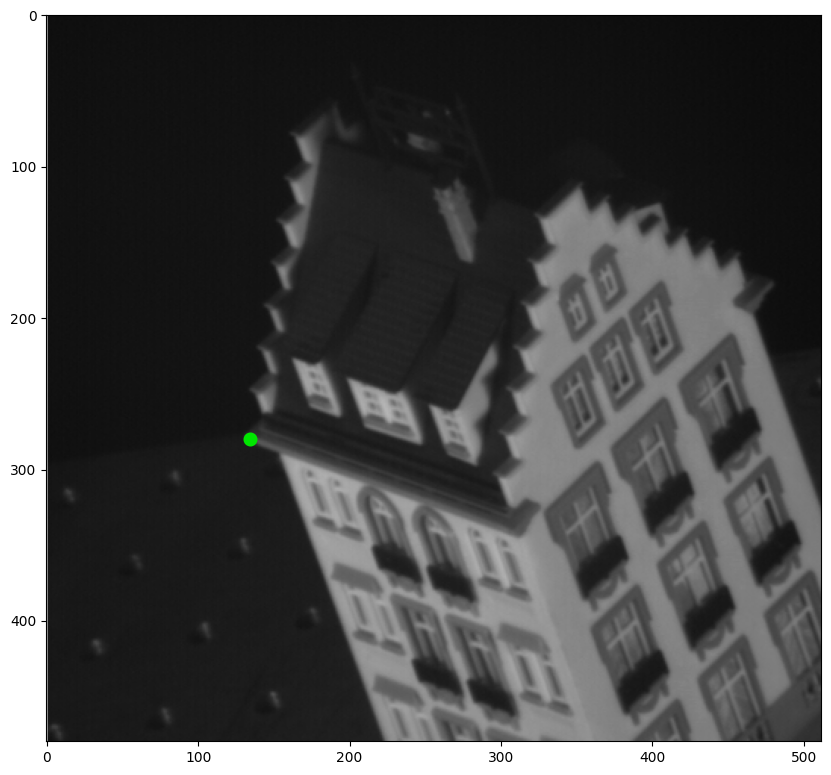

In [ ]:
# Let's make a synthetic motion, e.g., moving the whole image 1 pixel to the right
motion = np.array([[1, 0]])
key_pt_new = key_pt + motion

width, height = im0.shape[:2]

# shifted image by one pixel
# Translation matrix (shift 1 pixel to the right)
M = np.float32([[1, 0, motion[0,0]], [0, 1, 0]])  # Moves the image 1 pixel right

# Apply the affine transformation
shifted_image = cv2.warpAffine(im0, M, (height, width), borderValue=(255, 255, 255))

# visualize shifted im0
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(shifted_image / 255)
plt.scatter(key_pt_new[:, 0], key_pt_new[:, 1], color=(0,0.9,0), linewidths=3, s=50)
plt.show()

In [ ]:
print('new position: ', key_pt_new)
print('old position: ', key_pt)

new position:  [[134 280]]
old position:  [[133 280]]


At this moment, we know the solution from the tracking should be `[[134 280]]`.

Let's try to implement our tracking algorithm and use it to find it.

iteration: 0 , shift_uv_mean: 0.9798807918162377
iteration: 1 , shift_uv_mean: 0.0
prediction:  [[134. 280.]]
ground-truth:  [[134 280]]


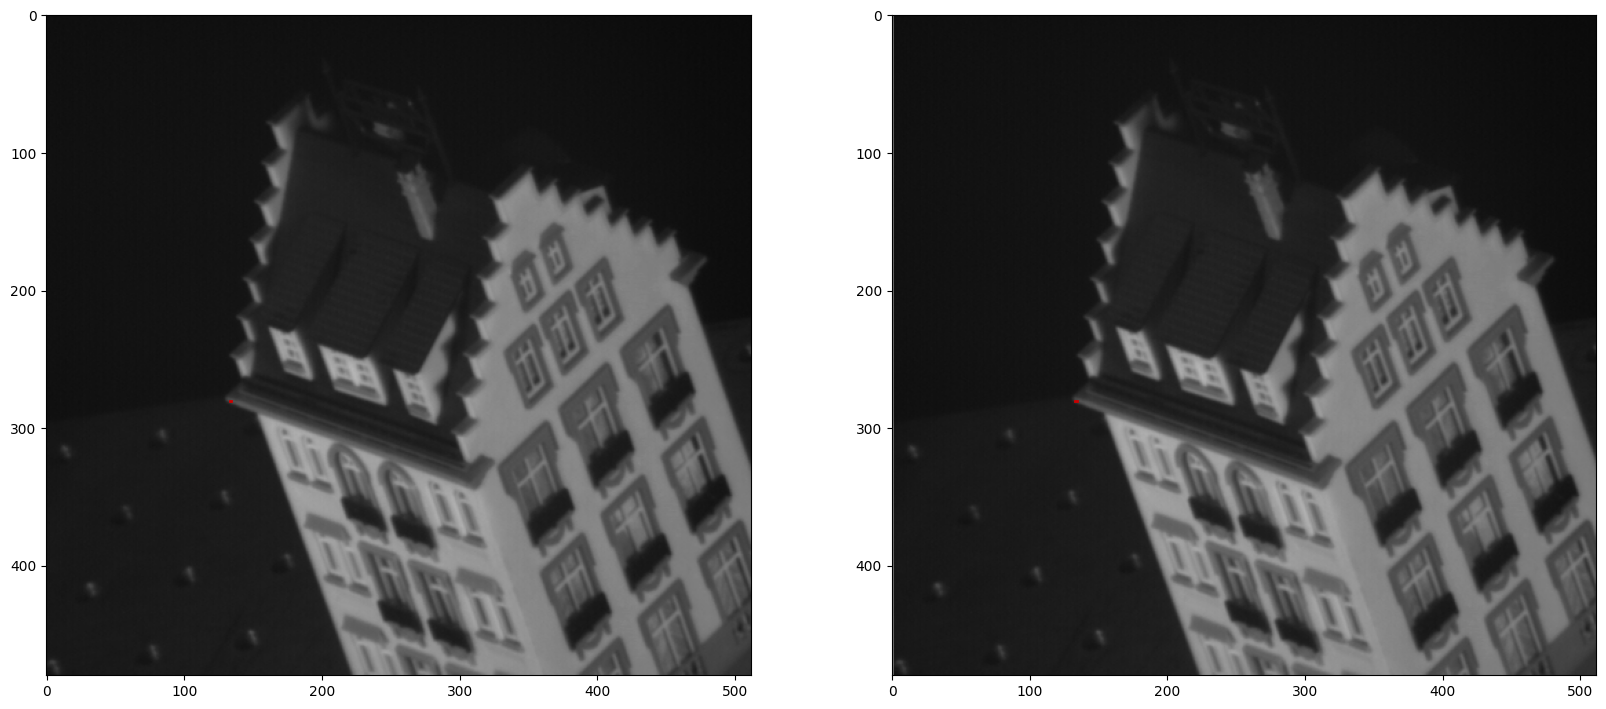

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
in_img = np.zeros(im.shape).astype(np.float32)
in_img[0] = im0
in_img[1] = shifted_image
in_img = in_img[:2]
tracked_x, tracked_y = trackPoints(pt_x=key_pt[:,0], pt_y=key_pt[:,1], im=in_img, ws=window_size, iteration=iteration)

print('prediction: ', np.round(np.concatenate((tracked_x[:, 1:],tracked_y[:, 1:]), axis=1)))
print('ground-truth: ', key_pt_new)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im0 / 255)
axs[1].imshow(shifted_image / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

### Sanity Check 4: Tracking 10 points with synthetic motion

(10, 2)


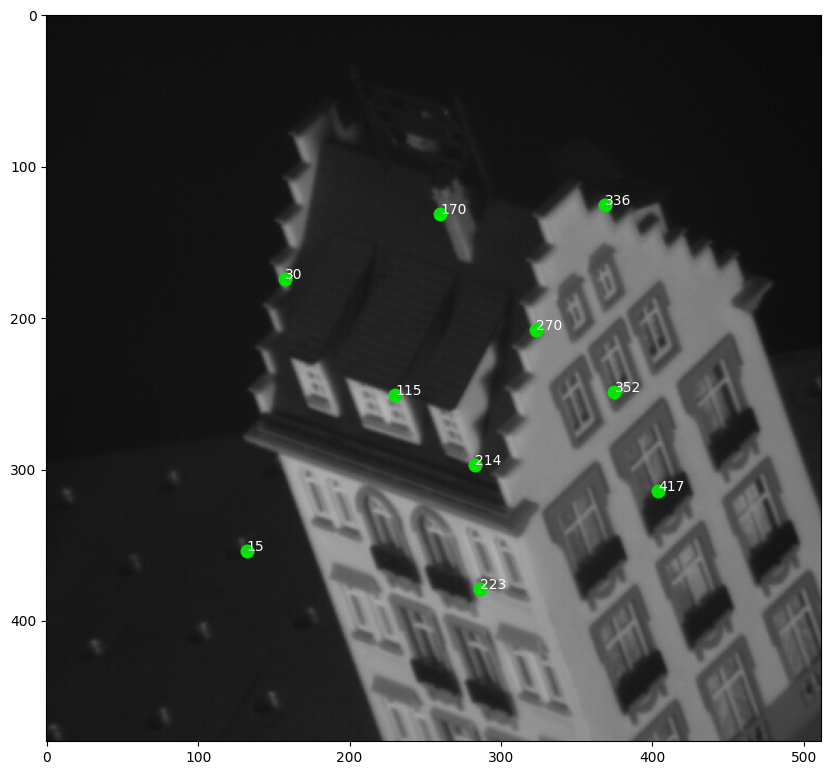

In [ ]:
# Congrats on solving all the above checking! We're almost there!
# Now let's try with more than one points
index = [15, 30, 170, 115, 214, 223, 270, 352, 336, 417]
key_pt = key_pts[index]
print(key_pt.shape)
im0 = im[0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(im0 / 255)
plt.scatter(key_pt[:, 0], key_pt[:, 1], color=(0,0.9,0), linewidths=3, s=50)
for i in range(key_pt.shape[0]):
    plt.text(key_pt[i,0], key_pt[i,1], str(index[i]), c='white')

plt.show()

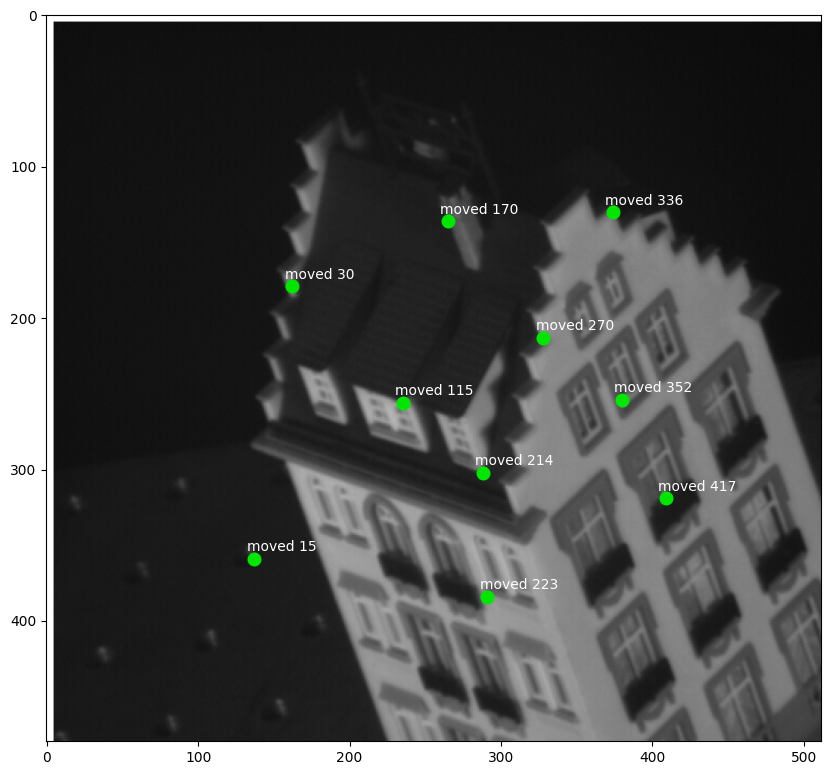

In [ ]:
# Let's make other synthetic motion, e.g., moving the whole image 5 pixel right, 5 pixel down
motion = np.array([[1, 0]])
key_pt_new = key_pt + motion

width, height = im0.shape[:2]

# Translation matrix
M = np.float32([[1, 0, motion[0,0]], [0, 1, motion[0,1]]])

# Apply the affine transformation
shifted_image = cv2.warpAffine(im0, M, (height, width), borderValue=(255, 255, 255))

# visualize shifted im0
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(shifted_image / 255)
plt.scatter(key_pt_new[:, 0], key_pt_new[:, 1], color=(0,0.9,0), linewidths=3, s=50)
for i in range(key_pt.shape[0]):
    plt.text(key_pt[i,0], key_pt[i,1], 'moved ' + str(index[i]), c='white')
plt.show()

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 100

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
in_img = np.zeros(im.shape).astype(np.float32)
in_img[0] = im0
in_img[1] = shifted_image
in_img = in_img[:2]
tracked_x, tracked_y = trackPoints(pt_x=key_pt[:,0], pt_y=key_pt[:,1], im=in_img, ws=window_size, iteration=iteration)

print('prediction: ', np.round(np.concatenate((tracked_x[:, 1:],tracked_y[:, 1:]), axis=1)))
print('ground-truth: ', key_pt_new)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im0 / 255)
axs[1].imshow(shifted_image / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

### Track real data - Track 1 point in two frames

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
in_img = np.zeros(im.shape).astype(np.float32)
in_img[0] = im[0]
in_img[1] = im[1]
in_img = in_img[:2]

start_id = 15
end_id = 16
tracked_x, tracked_y = trackPoints(pt_x=key_pts[start_id:end_id,0], pt_y=key_pts[start_id:end_id,1], im=in_img, ws=window_size, iteration=iteration)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im[0] / 255)
axs[1].imshow(im[1] / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

Original point: (132, 354)

Motion (u, v): (-2, -1)

Reference image

<img src="https://drive.google.com/uc?export=view&id=1tLy0248YEaUn01pYRhyV63gdvwQ8z6WJ" width="1600"/>


### Track real data - Track 5 points in two frames

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
in_img = np.zeros(im.shape).astype(np.float32)
in_img[0] = im[0]
in_img[1] = im[1]
in_img = in_img[:2]

start_id = 12
end_id = 17
tracked_x, tracked_y = trackPoints(pt_x=key_pts[start_id:end_id,0], pt_y=key_pts[start_id:end_id,1], im=in_img, ws=window_size, iteration=iteration)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im[0] / 255)
axs[1].imshow(im[1] / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

original point: (106, 408), (107, 412), (130, 348), (132, 354), (133, 280)

motion(u, v):    (-3, -1),  (-3, -1),   (-3, -1),   (-3, -1),   (-3, 0)

reference image:

 <img src="https://drive.google.com/uc?export=view&id=1b7Zf5nbExYjAQtcbdbaCbzdH6tQz49pr" width="1600"/>


### Track real data - Track all the points in two frames

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
in_img = np.zeros(im.shape).astype(np.float32)
in_img[0] = im[0]
in_img[1] = im[1]
in_img = in_img[:2]
tracked_x, tracked_y = trackPoints(pt_x=key_pts[:, 0], pt_y=key_pts[:, 1], im=in_img, ws=window_size, iteration=iteration)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im[0] / 255)
axs[1].imshow(im[1] / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

Reference image


<img src="https://drive.google.com/uc?export=view&id=1pOLMwbtqZzZ5ymUxkqcq_-wLssi1sTZ4" width="1600"/>



## Write-up (10 pts)

*   (10 pts) For all the keypoints, display (1) the keypoints at the first frame (as green) and (2) the tracked keypoints at the second frame (as red) on the first frame of the sequence.





```
# This is formatted as code
```

##[Bonus] Track real data - Track all points in all frames (10 points)


In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
tracked_x, tracked_y = trackPoints(pt_x=key_pts[:,0], pt_y=key_pts[:,1], im=im, ws=window_size, iteration=iteration)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im[0] / 255)
axs[1].imshow(im[-1] / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()

Reference image


<img src="https://drive.google.com/uc?export=view&id=1IKs-MJrdcOZjZSN9tWE7aXDki2Vb5UO_" width="1600"/>

## [Bonus] Write-up (20 pts)

*   (10 pts) For 20 random keypoints, draw the 2D path over the sequence of frames. That is, plot the progression of image coordinates for each of the 20 keypoints. Plot each of the paths on the same figure, overlaid on the first frame of the sequence.

In [ ]:
# Parameters setting
# You can start with a smaller number for fast debugging
window_size = 15
iteration = 10

'''
PLEASE DO NOT TOUCH CODES BELOW
'''
tracked_x, tracked_y = trackPoints(pt_x=key_pts[:,0], pt_y=key_pts[:,1], im=im, ws=window_size, iteration=iteration)

# Plot your results
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(im[0] / 255)
axs[1].imshow(im[-1] / 255)

for i in range(tracked_x.shape[1] - 1):
  axs[0].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
  axs[1].plot([tracked_x[:, i], tracked_x[:, i + 1]], [tracked_y[:, i], tracked_y[:, i + 1]], color=(0.8,0,0), linewidth=2)
plt.show()